# Importar "Boston Housing Price" dataset

Dataset que contiene información de casas de los suburbios de Boston a mediados de 1970 y sus precios. Los *features* (atributos) muestran informacion respecto al estado o contexto de la propiedad. Por ejemplo algunos atributos hablan de tasa de crimen, porcentaje de impuestos, cantidad de avitaciones y similares.

La **escala** de los atributos es diversa, algunos representan proporciones con valores de 0 a 1, otros toman valores entre 0 y 12, entre 0 y 100, por mencionar algunos ejemplos.

El dataset es relativamente **pequeño**. Hay 506 mustras repartidas 404 en *train* y 102 en *test*.

In [1]:
from keras.datasets import boston_housing

(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()


2025-07-06 12:40:19.882023: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751816419.899901  239436 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751816419.905391  239436 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751816419.919834  239436 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751816419.919852  239436 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751816419.919854  239436 computation_placer.cc:177] computation placer alr

In [2]:
train_data.shape

(404, 13)

In [3]:
test_data.shape

(102, 13)

Se conocen 13 atributos de cada muestra.

El atributo a predecir es el precio de las viviendas medido en miles de dolares.

In [4]:
train_targets

array([15.2, 42.3, 50. , 21.1, 17.7, 18.5, 11.3, 15.6, 15.6, 14.4, 12.1,
       17.9, 23.1, 19.9, 15.7,  8.8, 50. , 22.5, 24.1, 27.5, 10.9, 30.8,
       32.9, 24. , 18.5, 13.3, 22.9, 34.7, 16.6, 17.5, 22.3, 16.1, 14.9,
       23.1, 34.9, 25. , 13.9, 13.1, 20.4, 20. , 15.2, 24.7, 22.2, 16.7,
       12.7, 15.6, 18.4, 21. , 30.1, 15.1, 18.7,  9.6, 31.5, 24.8, 19.1,
       22. , 14.5, 11. , 32. , 29.4, 20.3, 24.4, 14.6, 19.5, 14.1, 14.3,
       15.6, 10.5,  6.3, 19.3, 19.3, 13.4, 36.4, 17.8, 13.5, 16.5,  8.3,
       14.3, 16. , 13.4, 28.6, 43.5, 20.2, 22. , 23. , 20.7, 12.5, 48.5,
       14.6, 13.4, 23.7, 50. , 21.7, 39.8, 38.7, 22.2, 34.9, 22.5, 31.1,
       28.7, 46. , 41.7, 21. , 26.6, 15. , 24.4, 13.3, 21.2, 11.7, 21.7,
       19.4, 50. , 22.8, 19.7, 24.7, 36.2, 14.2, 18.9, 18.3, 20.6, 24.6,
       18.2,  8.7, 44. , 10.4, 13.2, 21.2, 37. , 30.7, 22.9, 20. , 19.3,
       31.7, 32. , 23.1, 18.8, 10.9, 50. , 19.6,  5. , 14.4, 19.8, 13.8,
       19.6, 23.9, 24.5, 25. , 19.9, 17.2, 24.6, 13

Los precios promedio estan entre *10000$* y *50000$*. No estan ajustados por inflación.

# Preparar los datos

La normalizacion de los datos esta directamente relacionada a la velocidad de convergencia. Es buena practica normalizar todos los atributos de tipo numerico a una misma escala. La red PUEDE aprender escalas heterogeneas pero el aprendizaje es mas DIFICIL.

Un metodo bien aceptado para normalizar es a cada atributo restarle la media y dividir por la desviación estandar. Esto centra las muestras de cada atributo en 0 y con una desviación estandar unitaria.

In [5]:
train_data[0]

array([  1.23247,   0.     ,   8.14   ,   0.     ,   0.538  ,   6.142  ,
        91.7    ,   3.9769 ,   4.     , 307.     ,  21.     , 396.9    ,
        18.72   ])

In [6]:
mean = train_data.mean()
train_data -= mean
std = train_data.std()
train_data /= std

test_data -= mean
test_data /= std

In [7]:
train_data[0]

array([-0.47482083, -0.48335641, -0.42698208, -0.48335641, -0.47963044,
       -0.44081941,  0.15172056, -0.45581402, -0.45565404,  1.64280094,
       -0.33791894,  2.26541184, -0.35370929])

# Construir RED

Hay pocos datos disponibles. Cuando se tienen pocos datos el riesgo de *overfiting* aumenta. Reducir el tamaño de la red disminuye el *overfiting*. Por esto, se usa una red pequeña.

In [8]:
from keras import models
from keras import layers

# Se instanciara el mismo modelo muchas veces por lo que se usa una funcion.
"""Construir modelo.
Return:
- {}: modelo
"""
def build_model():
    model = models.Sequential()
    model.add(layers.Dense(64, activation='relu', input_shape=(train_data.shape[1],)))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1))
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

# Validación cruzada K-Carpetas

Para configurar los hiperparametros (como el numero de epochs) se puede separar un conjunto de val del conjunto de train. Pero en este caso hay pocos puntos de datos por lo que el conjunto de validación terminara siendo muy pequeño. Lo que proboca que los puntajes de validación varien mucho dependiendo de que ejemplos terminaron en el conjunto. La alta varianza en el conjunto de validacion hace poco confiable la evaluación del modelo.

La mejor practica en estas situaciones es *K-fold cross-validation* (validación cruzada en K carpetas). Consiste en dividir los datos disponibles (train) en K particiones (4 o 5), instanciar K modelos identicos y entrenar cada uno con $K-1$ particiones. La partición restante se usa para evaluar (val). Los puntajes de validacion son el promedio de las K validaciones realizadas.

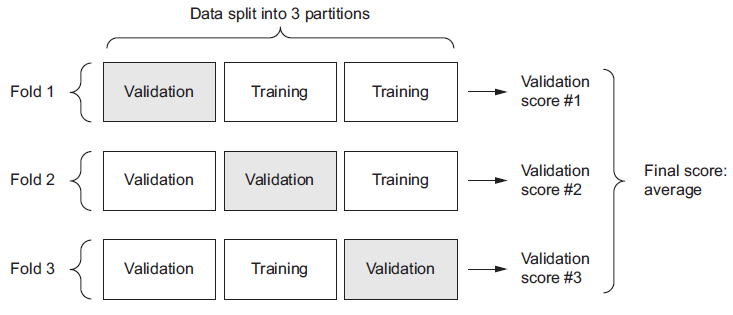

In [9]:
import numpy as np

k=4
num_val_samples = train_data.shape[0] // k
num_epochs = 100
all_scores = []

for i in range(k):
    print('processing fold #', i)
    val_data = train_data[i*num_val_samples:(i+1)*num_val_samples]
    val_targets = train_targets[i*num_val_samples:(i+1)*num_val_samples]

    partial_train_data = np.concatenate(
        [train_data[:i*num_val_samples],
        train_data[(i+1)*num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i*num_val_samples],
        train_targets[(i+1)*num_val_samples:]],
        axis=0) 

    model = build_model()
    model.fit(partial_train_data, partial_train_targets,
            epochs=num_epochs, batch_size=1, verbose=0)
    val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
    all_scores.append(val_mae)

processing fold # 0


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1751816422.647200  239436 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11398 MB memory:  -> device: 0, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:01:00.0, compute capability: 6.1
I0000 00:00:1751816423.895417  239464 service.cc:152] XLA service 0x7ff480006cd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751816423.895448  239464 service.cc:160]   StreamExecutor device (0): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2025-07-06 12:40:23.915902: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR cr

processing fold # 1
processing fold # 2
processing fold # 3


Promediando los errores *mae* que resultan de evaluar cada parametro se obtiene una metrica *mae* confiable.

In [10]:
all_scores

[4.045827865600586, 3.4644885063171387, 3.251753330230713, 4.817903518676758]

In [11]:
np.mean(all_scores)

np.float64(3.894993305206299)

Esto es *mae* (Error Absoluto Medio) el valor que toma refleja de forma directa el error promedio de la red. En este caso un error de $≈4$ significa que la red predice preccion con error en el rango de $±\$4000$. Es significativo considerando el rango de precios manejado de $\$10000$ a $\$50000$.

Se intenta entrenar la red un poco mas con 500 *epochs*. Modificado el código para guardar el historial de metricas por *epoch* de cada k-ejecución:

In [17]:
num_epochs = 1500
all_mae_histories = []

for i in range(k):
    print('processing fold #', i)
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    
    partial_train_data = np.concatenate(
        [train_data[:i*num_val_samples],
        train_data[(i+1)*num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i*num_val_samples],
        train_targets[(i+1)*num_val_samples:]],
        axis=0) 

    model = build_model()
    history = model.fit(partial_train_data, partial_train_targets,
                        validation_data=(val_data, val_targets),
                        epochs=num_epochs, batch_size=16, verbose=0)
    mae_history = history.history['val_mae']
    all_mae_histories.append(mae_history)

processing fold # 0
processing fold # 1
processing fold # 2
processing fold # 3


Promedio por *epoch*

In [18]:
average_mae_history = [np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]
average_mae_history

[np.float64(17.93963384628296),
 np.float64(13.184324026107788),
 np.float64(9.302145838737488),
 np.float64(7.619085073471069),
 np.float64(7.165812373161316),
 np.float64(6.541453242301941),
 np.float64(6.251830339431763),
 np.float64(6.16494357585907),
 np.float64(6.037307620048523),
 np.float64(5.811777591705322),
 np.float64(6.2394163608551025),
 np.float64(5.625800132751465),
 np.float64(5.973030090332031),
 np.float64(5.578104376792908),
 np.float64(5.55918562412262),
 np.float64(5.701204895973206),
 np.float64(5.820646524429321),
 np.float64(5.854309678077698),
 np.float64(5.49246621131897),
 np.float64(5.579750061035156),
 np.float64(5.77710223197937),
 np.float64(5.3895217180252075),
 np.float64(5.562111973762512),
 np.float64(5.538217902183533),
 np.float64(5.281452059745789),
 np.float64(5.45624840259552),
 np.float64(5.552636504173279),
 np.float64(5.500679850578308),
 np.float64(5.304264664649963),
 np.float64(5.794210433959961),
 np.float64(5.582166314125061),
 np.float6

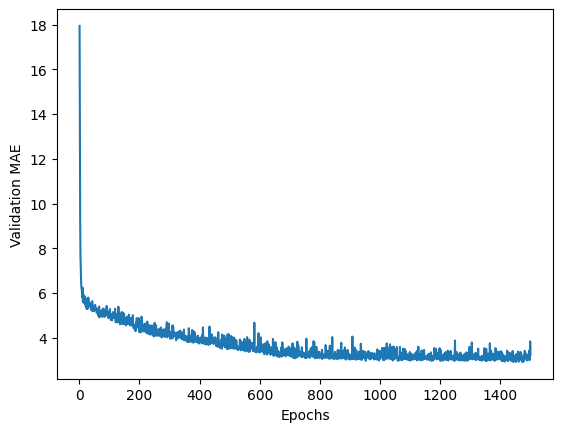

In [19]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(average_mae_history) + 1), average_mae_history)
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.show()

Es un poco ruidosa la curva (estamos usando dgs con batch=1) vamos a suvizarla con un movimiento exponencial del promedio de los putos anteriores.

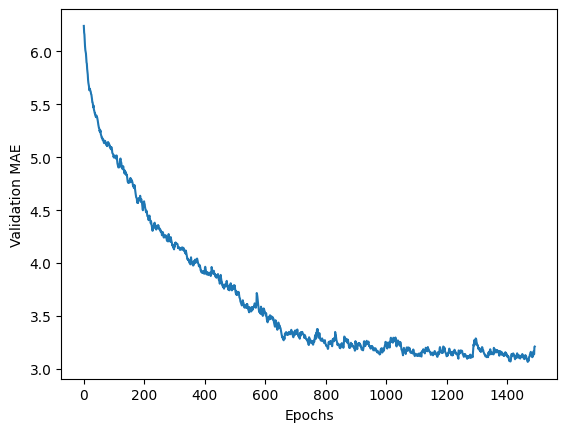

In [20]:
""" Suaviza una recta acorde a un factor en relacion al valor anterior de 
cada punto.

Parametros:
- points {NP.array}: arreglo de puntos.
- factor {float}?: porcentaje de suavizado. Default 0.9 (suavizado ALTO).

Return
- {NP.array}: arreglo suavizado.
"""
def smooth_curve(points, factor=0.9):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previus = smoothed_points[-1]
            smoothed_points.append(previus * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

smooth_mae_history = smooth_curve(average_mae_history[10:])

plt.plot(range(1, len(smooth_mae_history)+1), smooth_mae_history)
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.show()

El error esta continuamente bajando y perece que de segir entrenando seguiria mejorando. No obstante tarda mucho, capaz incrementar el learning rate sea prudente en este caso. En pos de disminuir la cantidad de epocas.


Una vez ajustados todos los hiperparametros ademas del numero de *epochs*, como cantidad y tamaño de capas ocultas, se puede entrenar un modelo de producción con la totalidad de parametros correctos:

In [ ]:
model = build_model()
model.fit(train_data, train_targets, epochs=1500, batch_size=16, verbose=0)   
test_mse_score, test_mae_score = model.evaluate(test_data, test_targets)
test_mae_score

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 22.2227 - mae: 3.0759


3.312100887298584

Con esto se obtubiebo un modelo que predice con un error de $\$3312$. 

Da lugar a mejora:
- Incrementando *learning rate*
- Incrementando la complejidad del modelo.